### Инициализация проекта

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
from imblearn.over_sampling import SMOTE

In [52]:
data = pd.read_csv('data/k4_eda.csv')

In [53]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62567 entries, 0 to 62566
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   UTC             62567 non-null  int64  
 1   Temperature[C]  62567 non-null  float64
 2   Humidity[%]     62567 non-null  float64
 3   TVOC[ppb]       62567 non-null  float64
 4   eCO2[ppm]       62567 non-null  float64
 5   Raw H2          62567 non-null  int64  
 6   Raw Ethanol     62567 non-null  int64  
 7   Pressure[hPa]   62567 non-null  float64
 8   PM1.0           62567 non-null  float64
 9   PM2.5           62567 non-null  float64
 10  NC0.5           62567 non-null  float64
 11  NC1.0           62567 non-null  float64
 12  NC2.5           62567 non-null  float64
 13  Fire Alarm      62567 non-null  bool   
dtypes: bool(1), float64(10), int64(3)
memory usage: 6.3 MB


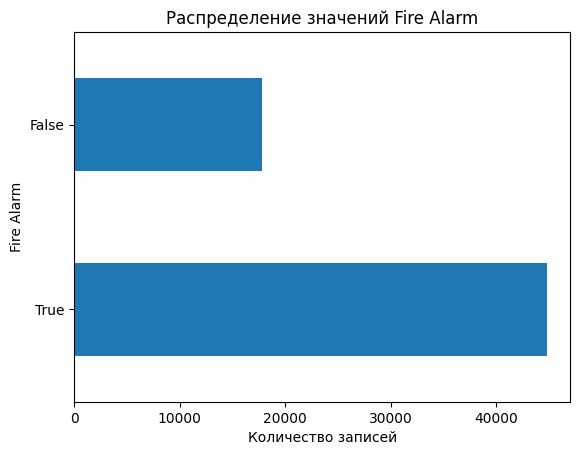

In [54]:
data['Fire Alarm'].value_counts().plot(kind='barh')

plt.title('Распределение значений Fire Alarm')
plt.xlabel('Количество записей')
plt.ylabel('Fire Alarm')

plt.show()

In [55]:
feature_data = data.drop(['Fire Alarm'], axis=1)
labels_data = data['Fire Alarm']

### Балансировка классов

In [56]:
labels_data.value_counts()

Fire Alarm
True     44757
False    17810
Name: count, dtype: int64

In [57]:
oversample = SMOTE()
transformed_feature_data, transformed_labels_data = oversample.fit_resample(feature_data, labels_data)

In [58]:
transformed_labels_data.value_counts()

Fire Alarm
False    44757
True     44757
Name: count, dtype: int64

In [59]:
data = pd.concat([transformed_feature_data, transformed_labels_data], axis=1)

In [60]:
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

In [61]:
data.to_csv('data/k4_balanced.csv', index=False)

### Разделение на обучающую и тестовую

In [62]:
X = data.drop(columns=['Fire Alarm', 'UTC'])
y = data['Fire Alarm']

In [63]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

In [64]:
from sklearn.model_selection import StratifiedKFold


kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [65]:
X

,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5
0,19.750000,50.860000,210.000000,400.000000,13150,20058,939.631000,1.120000,1.160000,7.720000,1.203000,0.027000
1,53.557638,22.716181,0.000000,591.925633,10924,15653,936.806294,0.860000,0.890000,5.901618,0.921000,0.021000
2,20.457000,53.180000,2.000000,400.000000,13191,20124,939.604000,0.810000,0.840000,5.550000,0.866000,0.020000
3,10.107028,46.548362,149.380857,408.273929,12782,20571,937.334381,1.762383,1.828931,12.103584,1.887657,0.042310
4,24.570000,53.480000,1172.000000,400.000000,12930,19436,938.656000,1.590000,1.660000,10.970000,1.710000,0.039000
...,...,...,...,...,...,...,...,...,...,...,...,...
89509,-7.833000,49.000000,165.000000,400.000000,13176,20098,939.651000,0.930000,0.970000,6.410000,1.000000,0.023000
89510,26.290000,44.090000,0.000000,400.000000,13467,21323,937.370000,2.190000,2.280000,15.070000,2.350000,0.053000
89511,-4.905279,46.089389,70.801953,400.000000,12785,20674,937.534467,2.191320,2.276650,15.085893,2.352183,0.053533
89512,26.945000,57.500000,0.000000,400.000000,13006,19932,939.754000,0.370000,0.390000,2.570000,0.400000,0.009000


In [69]:
from sklearn.preprocessing import RobustScaler


scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-0.03606181,  0.24972407, -0.0055814 , ..., -0.5072014 ,
        -0.51371189, -0.56457062],
       [ 2.39740085, -3.72100423, -0.20093023, ..., -0.73105718,
        -0.73709294, -0.7859846 ],
       [ 0.01482781,  0.57704602, -0.19906977, ..., -0.77434388,
        -0.78066017, -0.82288693],
       ...,
       [-1.81074066, -0.42334739, -0.13506795, ...,  0.39959254,
         0.39659236,  0.41455919],
       [ 0.48183192,  1.18654206, -0.20093023, ..., -1.14120314,
        -1.1497934 , -1.22881256],
       [-0.5941202 , -0.16366097,  0.84837209, ...,  0.23267249,
         0.22930736,  0.21037831]])